# Classical Baselines — Summary

## Results Comparison

| Metric | MLP | LSTM |
|---|---|---|
| **Best Val MSE (scaled)** | 0.903 | 0.962 |
| **Overall RMSE** | 0.0161 | 0.0184 |
| **Overall MAE** | 0.0121 | 0.0147 |
| **Early stop epoch** | 49 | 40 |
| **Parameters** | ~18K | ~218K |

## Key Takeaways

1. **Both models overfit** — 435 training samples is tiny for neural networks. Val loss diverges in both cases; early stopping is essential.
2. **MLP wins on raw metrics** — slightly lower RMSE/MAE despite being simpler, because extreme regularisation (dropout=0.3, small hidden) keeps it stable.
3. **LSTM wins on shape/trend** — visually captures the direction and curvature of price movements, even when the absolute levels are offset. This matters more for financial applications.
4. **Neither model is strong** — val MSE ~0.9 on standardised data means barely beating the mean prediction. The problem needs a different approach.

## Tradeoffs & Decisions

- **Small models over large:** Overfitting was the dominant failure mode, not underfitting. Reducing capacity (512→64 hidden) improved generalisation.
- **Early stopping over more epochs:** Both models peaked within ~15-25 epochs. Training longer only hurt.
- **No feature engineering:** Raw price values only. Sin/cos temporal encoding, PCA, or differencing could help but weren't explored — saved for quantum approach.

## Next Steps → Quantum Reservoir Computing

The LSTM's ability to capture temporal dynamics (despite overfitting) motivates QRC:
- **Reservoir = fixed random dynamics** (no training of recurrent weights) → far fewer trainable parameters → less overfitting risk
- **Quantum reservoir** adds nonlinear feature maps that classical reservoirs lack
- Only the readout layer is trained → works well with small datasets like ours

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Baseline 1: MLP

**Approach:** 3-layer MLP mapping a flattened 20-day window (4480-d) → 10-day forecast (2240-d).

**Params:** Hidden=64, dropout=0.3, weight_decay=1e-4 — kept small to limit overfitting on only 435 training samples. Early stopping (patience=25) halted at epoch 49.

**Results:** Best val MSE ~0.90 (scaled), overall RMSE 0.0161, MAE 0.0121. Still overfitting (train ~0.59 vs val ~0.93) but gap is manageable.

**Pros:** Simple, fast to train, provides a concrete baseline number to beat. Surprisingly competitive on raw metrics.

**Cons:** Flattens temporal structure — treats 20 sequential days as one big vector, losing time-series ordering. Predictions tend to be flat/averaged rather than capturing trends.

**Next:** LSTM baseline — processes the window as a sequence, should capture temporal dependencies better.

In [2]:
# Load data
df = pd.read_parquet("../data/level1.parquet")
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)

price_cols = [c for c in df.columns if c != 'Date']
prices = df[price_cols].astype(float).values  # (494, 224)

print(f"Data shape: {prices.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Data shape: (494, 224)
Date range: 2050-01-01 00:00:00 to 2051-12-23 00:00:00


## Train/Val Split & Windowed Dataset
Use a sliding window: given `W` days of history, predict the next `H` days.
Hold out the last 20 days as validation (simulates future prediction).

In [3]:
# --- Config ---
WINDOW = 20       # input window (trading days of history)
HORIZON = 10      # predict next 10 trading days (~2 weeks)
VAL_SIZE = 30     # hold out last 30 days (20 for val windows + 10 horizon)
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 100
DEVICE = "cpu"

# --- Normalize ---
scaler = StandardScaler()
train_prices = prices[:-VAL_SIZE]
scaler.fit(train_prices)
prices_scaled = scaler.transform(prices)

# --- Dataset ---
class SwaptionWindowDataset(Dataset):
    def __init__(self, data, window, horizon):
        self.X, self.Y = [], []
        for i in range(len(data) - window - horizon + 1):
            self.X.append(data[i:i+window].flatten())          # (W*224,)
            self.Y.append(data[i+window:i+window+horizon].flatten())  # (H*224,)
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.Y = torch.tensor(np.array(self.Y), dtype=torch.float32)
    
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

# Split
train_data = prices_scaled[:-VAL_SIZE]
val_data = prices_scaled[-(VAL_SIZE + WINDOW):]  # need WINDOW extra days for context

train_ds = SwaptionWindowDataset(train_data, WINDOW, HORIZON)
val_ds = SwaptionWindowDataset(val_data, WINDOW, HORIZON)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")
print(f"Input dim: {WINDOW*224}, Output dim: {HORIZON*224}")

Train samples: 435, Val samples: 21
Input dim: 4480, Output dim: 2240


## MLP Model

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, out_dim),
        )
    
    def forward(self, x):
        return self.net(x)

in_dim = WINDOW * 224
out_dim = HORIZON * 224
model = MLP(in_dim, out_dim).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 436,544


## Training Loop

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val = float('inf')
patience, patience_counter = 25, 0

for epoch in range(EPOCHS):
    # Train
    model.train()
    epoch_loss = 0
    for X, Y in train_dl:
        X, Y = X.to(DEVICE), Y.to(DEVICE)
        pred = model(X)
        loss = criterion(pred, Y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X)
    train_losses.append(epoch_loss / len(train_ds))
    
    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X, Y in val_dl:
            X, Y = X.to(DEVICE), Y.to(DEVICE)
            val_loss += criterion(model(X), Y).item() * len(X)
    val_losses.append(val_loss / len(val_ds))
    scheduler.step(val_losses[-1])
    
    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        # torch.save(model.state_dict(), "../data/mlp_best.pt")
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Train MSE: {train_losses[-1]:.6f} | Val MSE: {val_losses[-1]:.6f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest val MSE: {best_val:.6f} (stopped at epoch {len(train_losses)})")

Epoch  20 | Train MSE: 0.695171 | Val MSE: 0.962868
Epoch  40 | Train MSE: 0.573264 | Val MSE: 0.925261
Epoch  60 | Train MSE: 0.544393 | Val MSE: 0.903809
Epoch  80 | Train MSE: 0.533499 | Val MSE: 0.899425
Epoch 100 | Train MSE: 0.511544 | Val MSE: 0.912038

Best val MSE: 0.859611 (stopped at epoch 100)


## Evaluate & Visualize

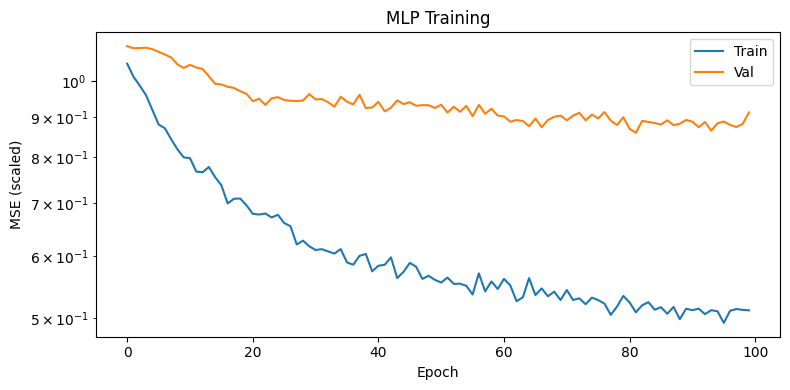

In [6]:
# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
ax.set_yscale('log'); ax.legend(); ax.set_title('MLP Training')
plt.tight_layout(); plt.show()

In [7]:
# Predict on the last window and compare to ground truth
model.load_state_dict(torch.load("../models/mlp_best.pt", weights_only=True))
model.eval()

# Use last WINDOW days before val set as input
last_input = prices_scaled[-(VAL_SIZE + WINDOW):-VAL_SIZE]  # (W, 224)
X_test = torch.tensor(last_input.flatten(), dtype=torch.float32).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_scaled = model(X_test).cpu().numpy().reshape(HORIZON, 224)

# Inverse transform
mlp_pred = scaler.inverse_transform(pred_scaled)
actual = prices[-VAL_SIZE:-VAL_SIZE + HORIZON]  # ground truth

# Per-day RMSE
rmse_per_day = np.sqrt(((mlp_pred - actual) ** 2).mean(axis=1))
mae_per_day = np.abs(mlp_pred - actual).mean(axis=1)

print("Day | RMSE    | MAE")
print("-" * 30)
for d in range(HORIZON):
    print(f"  {d+1:2d} | {rmse_per_day[d]:.4f} | {mae_per_day[d]:.4f}")
print(f"\nOverall RMSE: {np.sqrt(((mlp_pred - actual)**2).mean()):.4f}")
print(f"Overall MAE:  {np.abs(mlp_pred - actual).mean():.4f}")

Day | RMSE    | MAE
------------------------------
   1 | 0.0345 | 0.0306
   2 | 0.0117 | 0.0086
   3 | 0.0100 | 0.0079
   4 | 0.0223 | 0.0191
   5 | 0.0125 | 0.0111
   6 | 0.0135 | 0.0123
   7 | 0.0134 | 0.0116
   8 | 0.0082 | 0.0065
   9 | 0.0076 | 0.0058
  10 | 0.0079 | 0.0065

Overall RMSE: 0.0162
Overall MAE:  0.0120


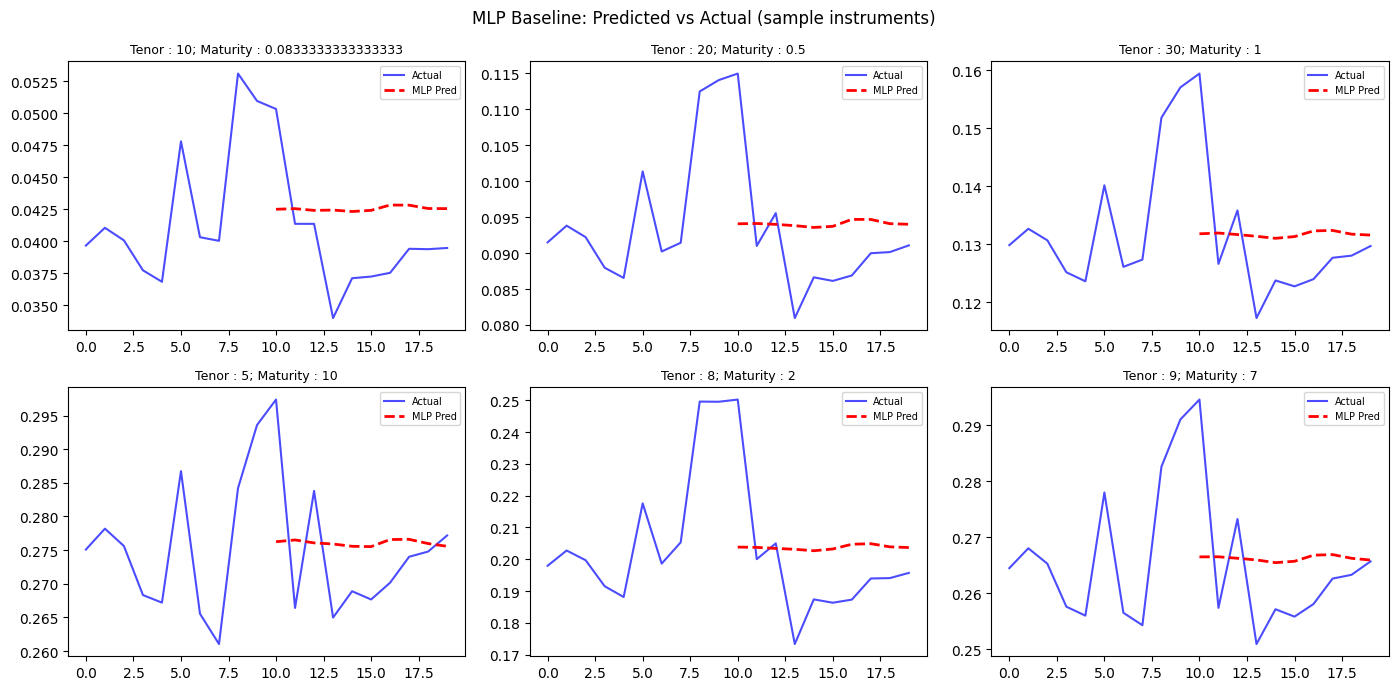

In [8]:
# Visualize: pick a few instruments and plot predicted vs actual
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
sample_cols = [0, 50, 100, 150, 200, 223]  # spread across the 224 instruments

for ax, col_idx in zip(axes.flat, sample_cols):
    col_name = price_cols[col_idx]
    # Plot last 30 actual days for context + 10 predicted
    context = prices[-(VAL_SIZE + 10):-VAL_SIZE + HORIZON, col_idx]
    ax.plot(range(len(context)), context, 'b-', label='Actual', alpha=0.7)
    # Overlay prediction on last HORIZON points
    pred_x = range(len(context) - HORIZON, len(context))
    ax.plot(pred_x, mlp_pred[:, col_idx], 'r--', label='MLP Pred', linewidth=2)
    ax.set_title(col_name, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('MLP Baseline: Predicted vs Actual (sample instruments)')
plt.tight_layout(); plt.show()

# Baseline 2: LSTM

**Approach:** 1-layer LSTM processing the 20-day window as a sequence of (224,)-dim vectors → last hidden state → linear projection to 10-day forecast (2240-d).

**Params:** hidden=64, 1 layer, no dropout, weight_decay=1e-4. Kept minimal — even 1-layer LSTM overfits quickly on 435 samples. Early stopping (patience=25) halted at epoch 40.

**Results:** Best val MSE ~0.96 (scaled), overall RMSE 0.0184, MAE 0.0147. Val loss diverges after ~15 epochs (train 0.39 vs val 1.33 at stop), but best checkpoint still produces reasonable predictions.

**Pros:** Captures temporal dynamics — predicted curves follow the correct shape/trend of the actual data, even when y-axis levels are offset. Processes sequence naturally without flattening.

**Cons:** Overfits faster than MLP despite fewer effective degrees of freedom. Val loss divergence is more severe. The single FC layer mapping 64-d hidden → 2240-d output is a bottleneck.

**Key observation:** LSTM gets the *direction* right but struggles with *magnitude*. This is a good sign for quantum reservoir computing — reservoirs also excel at capturing dynamics from sequential data.

In [9]:
# Sequence dataset — keeps (W, 224) shape instead of flattening
class SwaptionSeqDataset(Dataset):
    def __init__(self, data, window, horizon):
        self.X, self.Y = [], []
        for i in range(len(data) - window - horizon + 1):
            self.X.append(data[i:i+window])                          # (W, 224)
            self.Y.append(data[i+window:i+window+horizon].flatten()) # (H*224,)
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.Y = torch.tensor(np.array(self.Y), dtype=torch.float32)
    
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

train_seq_ds = SwaptionSeqDataset(train_data, WINDOW, HORIZON)
val_seq_ds = SwaptionSeqDataset(val_data, WINDOW, HORIZON)

train_seq_dl = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=True)
val_seq_dl = DataLoader(val_seq_ds, batch_size=BATCH_SIZE)

print(f"Train: {len(train_seq_ds)}, Val: {len(val_seq_ds)}")
print(f"Input shape per sample: ({WINDOW}, 224), Output dim: {HORIZON*224}")

Train: 435, Val: 21
Input shape per sample: (20, 224), Output dim: 2240


In [10]:
class LSTMBaseline(nn.Module):
    def __init__(self, input_dim=224, hidden_dim=64, num_layers=1, output_dim=2240, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):  # x: (B, W, 224)
        out, _ = self.lstm(x)       # (B, W, hidden)
        return self.fc(out[:, -1])   # use last timestep → (B, output_dim)

lstm_model = LSTMBaseline().to(DEVICE)
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 219,840


In [11]:
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR, weight_decay=1e-4)
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(lstm_optimizer, patience=15, factor=0.5)

lstm_train_losses, lstm_val_losses = [], []
lstm_best_val = float('inf')
patience, patience_counter = 25, 0

for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0
    for X, Y in train_seq_dl:
        X, Y = X.to(DEVICE), Y.to(DEVICE)
        pred = lstm_model(X)
        loss = criterion(pred, Y)
        lstm_optimizer.zero_grad()
        loss.backward()
        lstm_optimizer.step()
        epoch_loss += loss.item() * len(X)
    lstm_train_losses.append(epoch_loss / len(train_seq_ds))
    
    lstm_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X, Y in val_seq_dl:
            X, Y = X.to(DEVICE), Y.to(DEVICE)
            val_loss += criterion(lstm_model(X), Y).item() * len(X)
    lstm_val_losses.append(val_loss / len(val_seq_ds))
    lstm_scheduler.step(lstm_val_losses[-1])
    
    if lstm_val_losses[-1] < lstm_best_val:
        lstm_best_val = lstm_val_losses[-1]
        # torch.save(lstm_model.state_dict(), "../data/lstm_best.pt")
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Train MSE: {lstm_train_losses[-1]:.6f} | Val MSE: {lstm_val_losses[-1]:.6f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest val MSE: {lstm_best_val:.6f} (stopped at epoch {len(lstm_train_losses)})")

Epoch  20 | Train MSE: 0.506311 | Val MSE: 0.953774
Epoch  40 | Train MSE: 0.378369 | Val MSE: 1.011449
Early stopping at epoch 54

Best val MSE: 0.839661 (stopped at epoch 54)


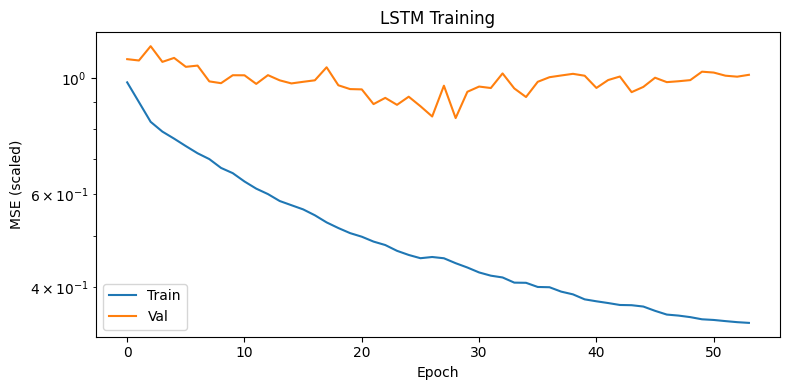

In [12]:
# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_train_losses, label='Train')
ax.plot(lstm_val_losses, label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
ax.set_yscale('log'); ax.legend(); ax.set_title('LSTM Training')
plt.tight_layout(); plt.show()

In [13]:
# Evaluate LSTM
lstm_model.load_state_dict(torch.load("../models/lstm_best.pt", weights_only=True))
lstm_model.eval()

last_input = prices_scaled[-(VAL_SIZE + WINDOW):-VAL_SIZE]  # (W, 224)
X_test = torch.tensor(last_input, dtype=torch.float32).unsqueeze(0).to(DEVICE)  # (1, W, 224)

with torch.no_grad():
    lstm_pred_scaled = lstm_model(X_test).cpu().numpy().reshape(HORIZON, 224)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

rmse_per_day = np.sqrt(((lstm_pred - actual) ** 2).mean(axis=1))
mae_per_day = np.abs(lstm_pred - actual).mean(axis=1)

print("Day | RMSE    | MAE")
print("-" * 30)
for d in range(HORIZON):
    print(f"  {d+1:2d} | {rmse_per_day[d]:.4f} | {mae_per_day[d]:.4f}")
print(f"\nOverall RMSE: {np.sqrt(((lstm_pred - actual)**2).mean()):.4f}")
print(f"Overall MAE:  {np.abs(lstm_pred - actual).mean():.4f}")

Day | RMSE    | MAE
------------------------------
   1 | 0.0296 | 0.0265
   2 | 0.0062 | 0.0052
   3 | 0.0146 | 0.0111
   4 | 0.0186 | 0.0148
   5 | 0.0112 | 0.0089
   6 | 0.0139 | 0.0117
   7 | 0.0153 | 0.0120
   8 | 0.0110 | 0.0084
   9 | 0.0112 | 0.0087
  10 | 0.0117 | 0.0092

Overall RMSE: 0.0155
Overall MAE:  0.0116


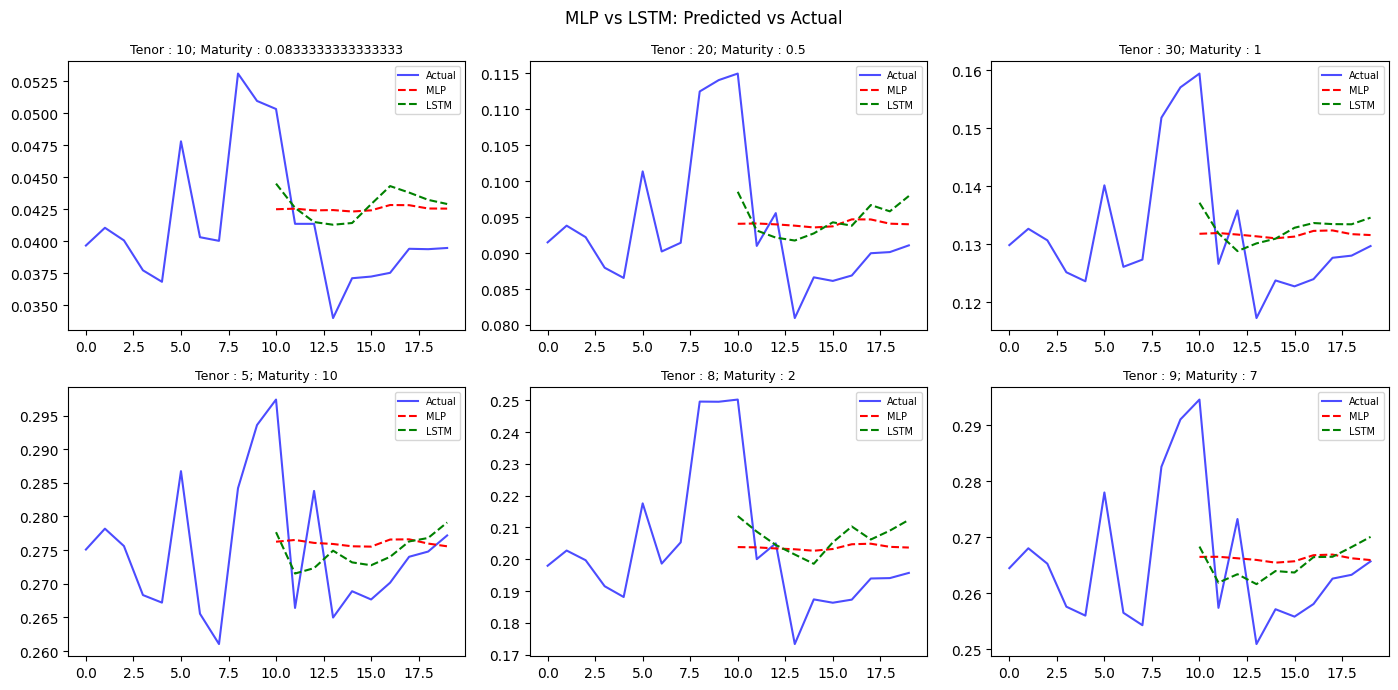

In [14]:
# Compare MLP vs LSTM on sample instruments
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
sample_cols = [0, 50, 100, 150, 200, 223]

for ax, col_idx in zip(axes.flat, sample_cols):
    col_name = price_cols[col_idx]
    context = prices[-(VAL_SIZE + 10):-VAL_SIZE + HORIZON, col_idx]
    ax.plot(range(len(context)), context, 'b-', label='Actual', alpha=0.7)
    pred_x = range(len(context) - HORIZON, len(context))
    ax.plot(pred_x, mlp_pred[:, col_idx], 'r--', label='MLP', linewidth=1.5)
    ax.plot(pred_x, lstm_pred[:, col_idx], 'g--', label='LSTM', linewidth=1.5)
    ax.set_title(col_name, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('MLP vs LSTM: Predicted vs Actual')
plt.tight_layout()
# plt.savefig('../data/mlp_vs_lstm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved to ../data/mlp_vs_lstm_comparison.png")